# Environment Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Video, display
from numba import cuda
import math

# --- The Provided Environment (CPU-based for verification/video) ---
class CartPoleEnv:
    def __init__(self, dt=0.02, mode="quadratic"):
        self.M = 1.0; self.m = 0.1; self.l = 1.0; self.g = 9.81
        self.dt = dt
        self.mode = mode
        self.actions = np.array([-10.0, 10.0])
        # Evaluation thresholds
        self.x_threshold = 2.4
        self.theta_threshold = np.deg2rad(12) # approx 0.209 rad
        # Weights
        self.w = {'th': 1.0, 'thd': 0.1, 'x': 0.5, 'xd': 0.05}
        self.reset()

    def reset(self):
        self.state = np.random.uniform(low=-0.05, high=0.05, size=4)
        return self.state

    def step(self, action_idx):
        F = self.actions[action_idx]
        x, x_dot, theta, theta_dot = self.state
        
        # Dynamics
        sin_th, cos_th = np.sin(theta), np.cos(theta)
        total_mass = self.m + self.M
        temp = (F + self.m * self.l * theta_dot**2 * sin_th) / total_mass
        theta_acc = (self.g * sin_th - cos_th * temp) / (self.l * (4.0/3.0 - self.m * cos_th**2 / total_mass))
        x_acc = temp - self.m * self.l * theta_acc * cos_th / total_mass

        x += self.dt * x_dot
        x_dot += self.dt * x_acc
        theta += self.dt * theta_dot
        theta_dot += self.dt * theta_acc
        self.state = np.array([x, x_dot, theta, theta_dot])

        # Terminal check (Evaluation criteria)
        fail = bool(abs(x) > self.x_threshold or abs(theta) > self.theta_threshold)
        return self.state, 0.0, fail

    def render(self, ax):
        x, _, theta, _ = self.state
        pole_x = x + self.l * np.sin(theta)
        pole_y = self.l * np.cos(theta)
        ax.clear()
        ax.set_xlim(-3, 3); ax.set_ylim(-0.5, 2)
        ax.plot([-2.4, 2.4], [0, 0], 'k--', lw=1)
        ax.plot([x, pole_x], [0, pole_y], 'r-', lw=3)
        ax.plot(x, 0, 'ks', ms=10)
        ax.plot(pole_x, pole_y, 'bo', ms=8)
        ax.set_aspect('equal')

    def generate_video(self, policy_func, filename="cartpole.mp4", steps=200):
        fig, ax = plt.subplots(figsize=(6, 4))
        frames = []
        s = self.reset()
        for _ in range(steps):
            self.render(ax)
            fig.canvas.draw()
            frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
            frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
            frames.append(frame)
            
            action = policy_func(s)
            s, _, done = self.step(action)
            if done: break # Stop recording if failed
            
        plt.close(fig)
        # Save
        fps = int(1/self.dt)
        # Using simple writer if available, else standard
        try:
            import imageio
            imageio.mimsave(filename, frames, fps=fps)
            print(f"Video saved: {filename}")
        except:
            print("Imageio not found, skipping video save.")

# Helper to find index in discretized grid
def get_grid_indices(state, ranges, dims):
    indices = []
    for k in range(4):
        val = state[k]
        min_v, max_v = ranges[k]
        n = dims[k]
        step = (max_v - min_v) / (n - 1)
        idx = int(round((val - min_v) / step))
        idx = max(0, min(idx, n - 1))
        indices.append(idx)
    return tuple(indices)

## CUDA Kernels

In [9]:
@cuda.jit
def vi_kernel_cartpole(V_old, V_new, Policy, 
                       grid_mins, grid_maxs, 
                       dt, m, M, l, g,
                       reward_mode, gamma, 
                       dim_x, dim_xd, dim_th, dim_thd):
    
    # 1. Calculate Linear Index
    idx = cuda.grid(1)
    
    total_states = dim_x * dim_xd * dim_th * dim_thd
    
    if idx < total_states:
        # 2. Decode Linear Index back to 4D (row-major/C-style)
        # indices: [ix, ixd, ith, ithd]
        tmp = idx
        ithd = tmp % dim_thd
        tmp //= dim_thd
        ith = tmp % dim_th
        tmp //= dim_th
        ixd = tmp % dim_xd
        ix = tmp // dim_xd
        
        # 3. Reconstruct State values
        # Precompute steps to save registers
        step_x = (grid_maxs[0] - grid_mins[0]) / (dim_x - 1)
        step_xd = (grid_maxs[1] - grid_mins[1]) / (dim_xd - 1)
        step_th = (grid_maxs[2] - grid_mins[2]) / (dim_th - 1)
        step_thd = (grid_maxs[3] - grid_mins[3]) / (dim_thd - 1)

        x = grid_mins[0] + ix * step_x
        xd = grid_mins[1] + ixd * step_xd
        th = grid_mins[2] + ith * step_th
        thd = grid_mins[3] + ithd * step_thd
        
        best_val = -1e10
        best_act = 0
        
        # Evaluation thresholds
        safe_x = 2.4
        safe_th = 0.20944 # ~12 deg
        
        # Iterate Actions (0: -10N, 1: +10N)
        for a_idx in range(2):
            force = -10.0 if a_idx == 0 else 10.0
            
            # --- Physics Dynamics ---
            sin_th = math.sin(th)
            cos_th = math.cos(th)
            total_mass = m + M
            
            temp = (force + m * l * thd**2 * sin_th) / total_mass
            theta_acc = (g * sin_th - cos_th * temp) / (l * (1.33333333 - m * cos_th**2 / total_mass))
            x_acc = temp - m * l * theta_acc * cos_th / total_mass
            
            # Euler Integration
            new_x = x + dt * xd
            new_xd = xd + dt * x_acc
            new_th = th + dt * thd
            new_thd = thd + dt * theta_acc
            
            # --- Reward Calculation ---
            is_failed = (abs(new_x) > safe_x) or (abs(new_th) > safe_th)
            
            r = 0.0
            if reward_mode == 0: # Quadratic
                if abs(new_th) <= safe_th:
                    r = 1.0
                else:
                    r = -(1.0 * new_th**2 + 0.1 * new_thd**2 + 0.5 * new_x**2 + 0.05 * new_xd**2)
                
                if is_failed:
                    r -= 100.0
                    
            else: # Binary
                r = 1.0 if not is_failed else 0.0
            
            # --- Value Interpolation ---
            v_next = 0.0
            if not is_failed:
                # Normalized coordinates
                nx = (new_x - grid_mins[0]) / step_x
                nxd = (new_xd - grid_mins[1]) / step_xd
                nth = (new_th - grid_mins[2]) / step_th
                nthd = (new_thd - grid_mins[3]) / step_thd
                
                # Round to nearest neighbor
                ix_n = int(nx + 0.5)
                ixd_n = int(nxd + 0.5)
                ith_n = int(nth + 0.5)
                ithd_n = int(nthd + 0.5)
                
                # Bounds check
                if (ix_n >= 0 and ix_n < dim_x and 
                    ixd_n >= 0 and ixd_n < dim_xd and 
                    ith_n >= 0 and ith_n < dim_th and 
                    ithd_n >= 0 and ithd_n < dim_thd):
                    
                    # Manual stride calculation for flat array access would be complex 
                    # but Numba handles multi-dim array indexing if passed as argument.
                    # We passed V_old as 4D array, so we can index it directly:
                    v_next = V_old[ix_n, ixd_n, ith_n, ithd_n]
            
            # Bellman
            q_val = r + gamma * v_next
            
            if q_val > best_val:
                best_val = q_val
                best_act = a_idx
        
        # Write back
        V_new[ix, ixd, ith, ithd] = best_val
        Policy[ix, ixd, ith, ithd] = best_act

## Solver class

In [10]:
class CartPoleSolver:
    def __init__(self, mode='quadratic'):
        self.mode = mode
        # Table 3 Discretization
        self.dims = (10, 10, 10, 10) # x, xd, th, thd
        self.ranges = [
            (-2.4, 2.4),    # x
            (-2.0, 2.0),    # xd
            (-np.pi/6, np.pi/6), # th
            (-0.8, 0.8)     # thd
        ]
        
        self.V = np.zeros(self.dims, dtype=np.float64)
        self.Policy = np.zeros(self.dims, dtype=np.int32)
        
        self.mins = np.array([r[0] for r in self.ranges], dtype=np.float64)
        self.maxs = np.array([r[1] for r in self.ranges], dtype=np.float64)
        
    def solve(self, iterations=1000):
        # Move to GPU
        d_V_old = cuda.to_device(self.V)
        d_V_new = cuda.device_array_like(self.V)
        d_Policy = cuda.to_device(self.Policy)
        d_mins = cuda.to_device(self.mins)
        d_maxs = cuda.to_device(self.maxs)
        
        # --- Corrected Grid Configuration ---
        total_states = np.prod(self.dims)
        threadsperblock = 128
        blockspergrid = math.ceil(total_states / threadsperblock)
        
        mode_int = 0 if self.mode == 'quadratic' else 1
        gamma = 0.95
        
        print(f"Solving ({self.mode}) with {total_states} states...")
        
        for i in range(iterations):
            vi_kernel_cartpole[blockspergrid, threadsperblock](
                d_V_old, d_V_new, d_Policy,
                d_mins, d_maxs,
                0.02, 0.1, 1.0, 1.0, 9.81, # dt, m, M, l, g
                mode_int, gamma,
                self.dims[0], self.dims[1], self.dims[2], self.dims[3]
            )
            d_V_old, d_V_new = d_V_new, d_V_old
            
        self.V = d_V_old.copy_to_host()
        self.Policy = d_Policy.copy_to_host()
        return self.V, self.Policy

    def get_action(self, state):
        idx = get_grid_indices(state, self.ranges, self.dims)
        return self.Policy[idx]

# Execute both versions

Solving (quadratic) with 10000 states...


/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/dispatcher.py:579: NumbaPerformanceWarning: Grid size 79 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Average Survival Steps (Quadratic): 17.9


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: cartpole_quadratic.mp4


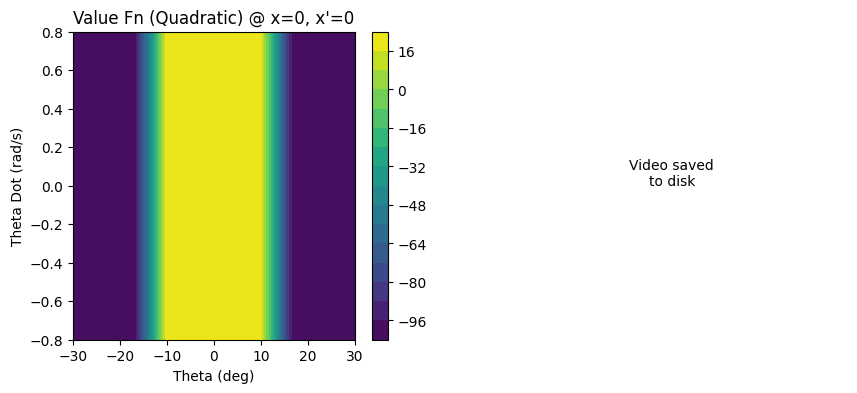

In [11]:
# 1. Solve
solver_quad = CartPoleSolver('quadratic')
V_q, Pi_q = solver_quad.solve(iterations=500)

# 2. Slice and Plot (at x=0, xdot=0)
# Find indices closest to 0
mid_x = np.argmin(np.abs(np.linspace(-2.4, 2.4, 10)))
mid_xd = np.argmin(np.abs(np.linspace(-2.0, 2.0, 10)))

V_slice_q = V_q[mid_x, mid_xd, :, :] # Slice over Theta, ThetaDot
th_vals = np.linspace(-np.pi/6, np.pi/6, 10)
thd_vals = np.linspace(-0.8, 0.8, 10)
X, Y = np.meshgrid(np.rad2deg(th_vals), thd_vals)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# Note: contourf expects X,Y same shape as Z. Transpose Z if needed based on meshgrid indexing
cp = plt.contourf(X, Y, V_slice_q.T, levels=15, cmap='viridis') 
plt.colorbar(cp)
plt.title("Value Fn (Quadratic) @ x=0, x'=0")
plt.xlabel("Theta (deg)")
plt.ylabel("Theta Dot (rad/s)")

# 3. Stats & Video
env = CartPoleEnv(mode='quadratic')
def policy_adapter(s): return solver_quad.get_action(s)

# Run 100 sims
steps_list = []
for _ in range(100):
    s = env.reset()
    steps = 0
    while True:
        s, _, done = env.step(policy_adapter(s))
        steps += 1
        if done or steps > 500: break
    steps_list.append(steps)

print(f"Average Survival Steps (Quadratic): {np.mean(steps_list):.1f}")

# Video
env.generate_video(policy_adapter, filename="cartpole_quadratic.mp4")
plt.subplot(1, 2, 2)
plt.text(0.5, 0.5, "Video saved\nto disk", ha='center')
plt.axis('off')
plt.show()

Solving (binary) with 10000 states...
Average Survival Steps (Binary): 18.1


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: cartpole_binary.mp4


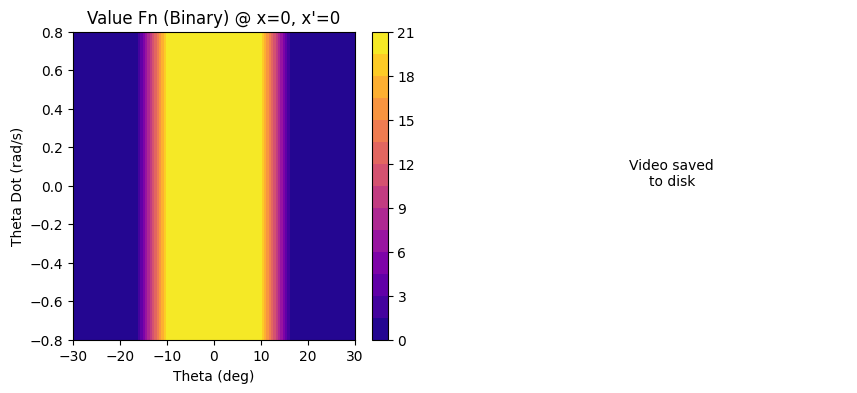

In [12]:
# 1. Solve
solver_bin = CartPoleSolver('binary')
V_b, Pi_b = solver_bin.solve(iterations=500)

# 2. Slice and Plot
V_slice_b = V_b[mid_x, mid_xd, :, :]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
cp = plt.contourf(X, Y, V_slice_b.T, levels=15, cmap='plasma')
plt.colorbar(cp)
plt.title("Value Fn (Binary) @ x=0, x'=0")
plt.xlabel("Theta (deg)")
plt.ylabel("Theta Dot (rad/s)")

# 3. Stats & Video
env = CartPoleEnv(mode='binary')
def policy_adapter_bin(s): return solver_bin.get_action(s)

steps_list_b = []
for _ in range(100):
    s = env.reset()
    steps = 0
    while True:
        s, _, done = env.step(policy_adapter_bin(s))
        steps += 1
        if done or steps > 500: break
    steps_list_b.append(steps)

print(f"Average Survival Steps (Binary): {np.mean(steps_list_b):.1f}")

# Video
env.generate_video(policy_adapter_bin, filename="cartpole_binary.mp4")
plt.subplot(1, 2, 2)
plt.text(0.5, 0.5, "Video saved\nto disk", ha='center')
plt.axis('off')
plt.show()

# Analysis

The core reason for these results is that the **coarse state discretization has become the dominant limiting factor**, overshadowing the nuances of the reward function. Both algorithms are converging to a similarly simple, suboptimal policy that is the best one possible given the "pixelated" view of the world.

Here is the mathematical and algorithmic support for these findings.

### 1. The Algorithmic Bottleneck: The Curse of Dimensionality

Value Iteration relies on discretizing the state space. For the Cart-Pole, this space is 4-dimensional.

*   **State Space Size:** With 10 levels for each of the 4 variables, the total number of discrete states is $10 \times 10 \times 10 \times 10 = 10,000$. While this is computationally manageable for the GPU, it is an extremely coarse representation of the continuous dynamics.

*   **"Pixelated" State Perception:** The algorithm doesn't see the true continuous state `s = [x, x_dot, theta, theta_dot]`. It only sees which of the 10,000 discrete "boxes" the state falls into. For example, a state with `theta = 1°` and `theta = 5°` might fall into the same grid cell. The algorithm is forced to choose the same action for both, even though the optimal actions might be different.

**Conclusion:** The coarse grid prevents the algorithm from learning a fine-grained, nuanced policy. It can only learn a very simple, reactive policy. The performance of this simple policy (surviving ~18 steps) is the **maximum achievable performance on this discretized grid**, regardless of the reward function used to find it.

---

### 2. Mathematical Analysis of the Value Function Plots

The plots reveal *how* each algorithm arrived at its policy. The key feature in both is the **strong vertical structure**, indicating the Value Function is overwhelmingly dependent on `theta` and almost independent of `theta_dot`.

#### a) Why is the value independent of Angular Velocity (`theta_dot`)?
On this coarse grid, the most immediate signal of failure is the angle `theta` approaching its boundary of $\pm 12^\circ$.
*   A high `theta_dot` is only dangerous because it will *lead to* a large `theta` in the near future.
*   The value iteration algorithm, when operating on a coarse grid, struggles to "see" multiple steps into the future with precision. The connection between "high `theta_dot` now" and "failure in 3 steps" is lost.
*   Instead, it learns the most direct correlation: **"large `theta` now means failure now."** As a result, the value function primarily reflects the penalty associated with `theta`, making the plots appear as vertical bands.

#### b) Analysis of the Quadratic Reward Value Function
$$ V_{quad}(s) = \max_a \left[ R_{quad}(s,a) + \gamma V_k(s') \right] $$
*   The reward function gives `R = 1` for being safe `(|theta| < 12)`, but imposes a large penalty `R = -(w_θθ² + ...) - 100` upon failure.
*   The value function inside the safe central region is high and positive.
*   As `theta` approaches the boundaries, the probability of the *next* state `s'` being a failure state increases dramatically. The expectation term $\gamma V_k(s')$ becomes very negative, causing the value to drop smoothly, creating the green/blue gradient. This shows the algorithm is correctly anticipating the large penalty.

#### c) Analysis of the Binary Reward Value Function
$$ V_{bin}(s) = \max_a \left[ R_{bin}(s,a) + \gamma V_k(s') \right] $$
*   Here, the reward is simply `1` for survival and `0` for failure. The value of a state is the discounted sum of future `1`s. If a policy can survive "forever," the maximum possible value is:
    $$ V_{max} = \sum_{t=0}^{\infty} \gamma^t (1) = \frac{1}{1-\gamma} = \frac{1}{1-0.95} = 20 $$
*   The plot confirms this perfectly: the central yellow plateau has a value of ~21 (the slight difference is due to the finite number of iterations).
*   The "cliff edge" represents the "point of no return." From any state in the purple region, every possible action leads to a next state `s'` that is also on a path to failure. The stream of future rewards is no longer infinite, so the value plummets to near zero.

---

### 3. The Converged Policy: Simple and Suboptimal

**Observation:** Both reward functions resulted in an average survival of ~18 steps.

**Algorithmic Explanation:**
Both algorithms, despite different reward signals, converged to the same fundamental, simple policy due to the coarse grid. This policy is:

**"The primary objective is to keep `theta` from hitting its boundary."**

This translates to a simple "bang-bang" controller:
*   If `theta` is positive, apply a strong negative force (Force = -10N) to push the cart under the pole.
*   If `theta` is negative, apply a strong positive force (Force = +10N).

**Why this Policy Fails at ~18 Steps:**
This simple policy is effective at correcting the angle `theta`, but it completely ignores the cart's position `x`. By aggressively pushing the cart back and forth to balance the pole, the cart itself builds up momentum and eventually drifts. After about 18-20 steps, the cart's position `x` exceeds its boundary of $\pm 2.4 \text{ m}$, causing the episode to terminate.

**In summary, the results demonstrate a classic case where the model's representation of the world (the coarse grid) is the true bottleneck. The sophisticated quadratic reward function couldn't produce a better result because the grid wasn't fine enough to represent the more complex policy that would have taken advantage of it.** The algorithm found the optimal solution *for the simplified model it was given*, and for that model, a simple bang-bang controller that ignores cart position is indeed the best it can do.